In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
data = pd.read_csv('umsatzdaten_gekuerzt.csv')

In [26]:
##     TASK1

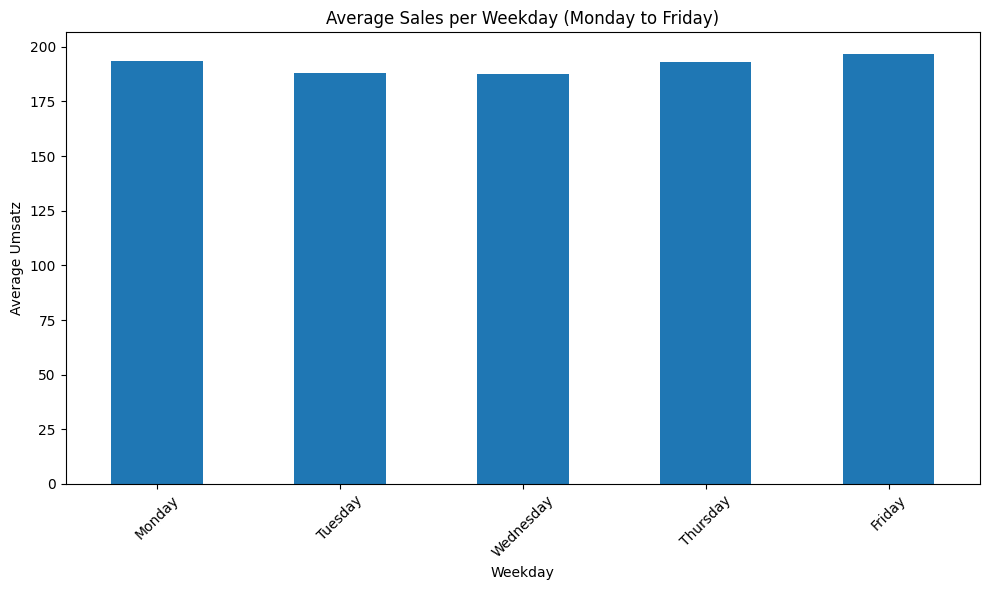

In [30]:
# Step 1: Convert 'Datum' column to datetime format
data['Datum'] = pd.to_datetime(data['Datum'])

# Step 2: Extract the weekday name
data['Wochentag'] = data['Datum'].dt.day_name()

# Step 3: Group by weekday and calculate average 'Umsatz'
average_sales = data.groupby('Wochentag')['Umsatz'].mean()

# Reorder the days for better visualization
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
average_sales = average_sales.reindex(weekday_order)

# Filter to include only Monday to Friday
weekday_order_weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
average_sales_weekdays = average_sales.reindex(weekday_order_weekdays)

# Plot only weekdays
plt.figure(figsize=(10, 6))
average_sales_weekdays.plot(kind='bar')
plt.title('Average Sales per Weekday (Monday to Friday)')
plt.xlabel('Weekday')
plt.ylabel('Average Umsatz')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [31]:
data.head()

,id,Datum,Warengruppe,Umsatz,Wochentag
0,1307011,2013-07-01,1,148.828353,Monday
1,1307021,2013-07-02,1,159.793757,Tuesday
2,1307031,2013-07-03,1,111.885594,Wednesday
3,1307041,2013-07-04,1,168.864941,Thursday
4,1307051,2013-07-05,1,171.280754,Friday


In [32]:
## TASK2

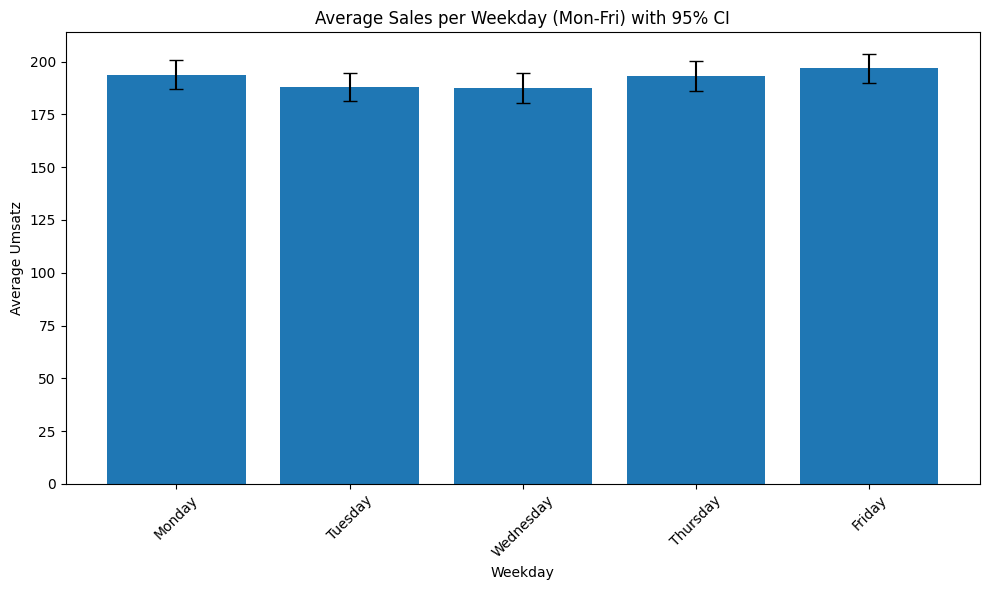

In [36]:
import numpy as np
import scipy.stats as stats

# Group by weekday (Monday to Friday) and calculate mean and confidence interval
weekday_data = data[data['Wochentag'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]

# Calculate mean and 95% confidence intervals
summary_stats = weekday_data.groupby('Wochentag')['Umsatz'].agg(['mean', 'count', 'std'])
summary_stats['ci95'] = 1.96 * summary_stats['std'] / np.sqrt(summary_stats['count'])

# Reorder for plotting
summary_stats = summary_stats.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])

# Plot with error bars for confidence intervals
plt.figure(figsize=(10, 6))
plt.bar(summary_stats.index, summary_stats['mean'], yerr=summary_stats['ci95'], capsize=5)
plt.title('Average Sales per Weekday (Mon-Fri) with 95% CI')
plt.xlabel('Weekday')
plt.ylabel('Average Umsatz')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


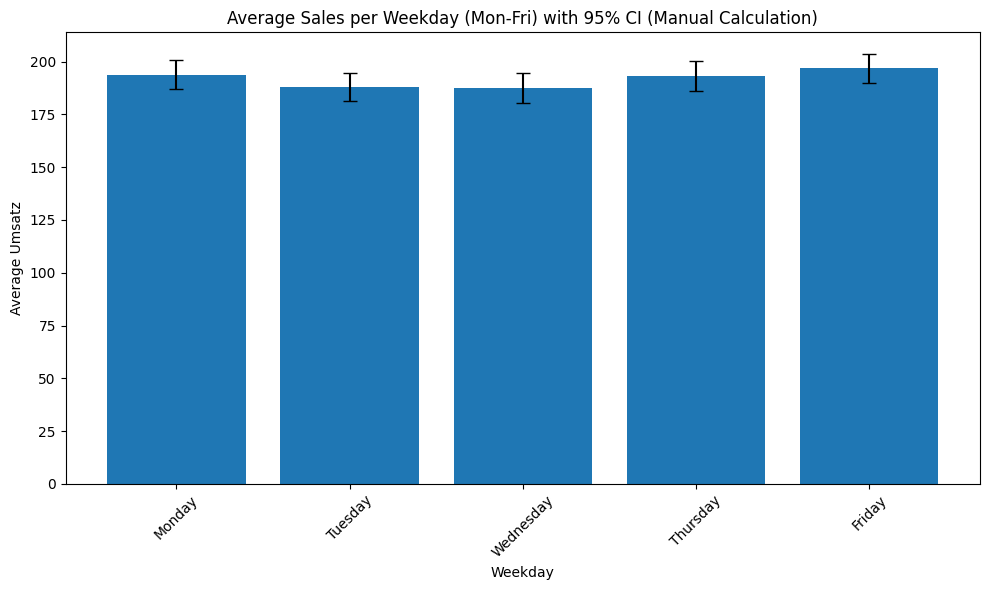

In [38]:
# Calculate the summary statistics manually using pandas
weekday_data = data[data['Wochentag'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]

# Group and calculate mean, count, and std
summary_stats_manual = weekday_data.groupby('Wochentag')['Umsatz'].agg(['mean', 'count', 'std'])

# Calculate 95% confidence interval manually
summary_stats_manual['ci95'] = 1.96 * (summary_stats_manual['std'] / summary_stats_manual['count']**0.5)

# Reorder the weekdays
summary_stats_manual = summary_stats_manual.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])

# Plot
plt.figure(figsize=(10, 6))
plt.bar(summary_stats_manual.index, summary_stats_manual['mean'], yerr=summary_stats_manual['ci95'], capsize=5)
plt.title('Average Sales per Weekday (Mon-Fri) with 95% CI (Manual Calculation)')
plt.xlabel('Weekday')
plt.ylabel('Average Umsatz')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This one is optional(generated only using pandas and matplotlib!)

In [39]:
### TASK3

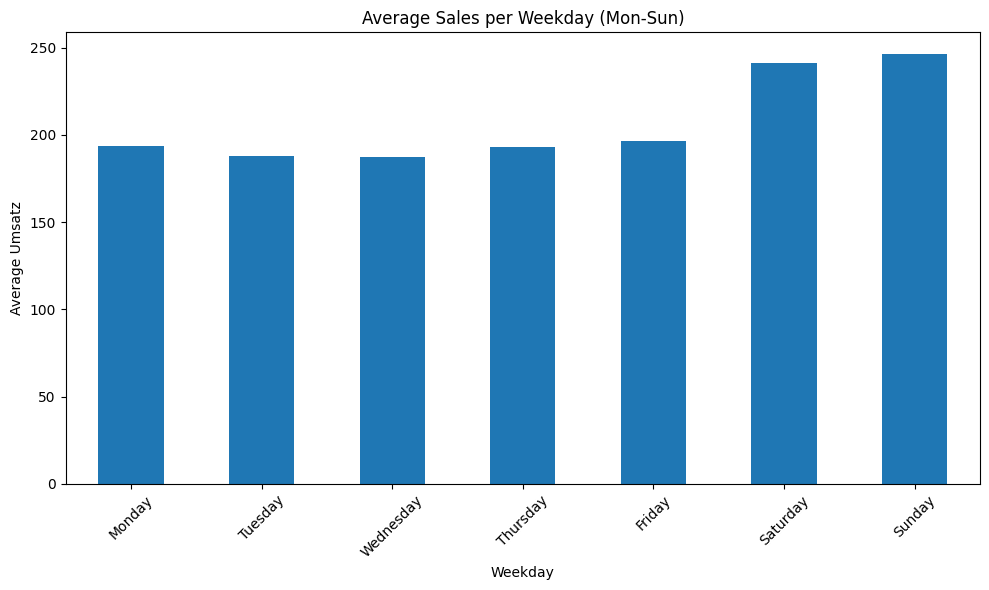

In [40]:
# Reorder the days for better visualization
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
average_sales = average_sales.reindex(weekday_order)

# Filter to include only Monday to Friday
weekday_order_weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
average_sales_weekdays = average_sales.reindex(weekday_order_weekdays)

# Plot only weekdays
plt.figure(figsize=(10, 6))
average_sales.plot(kind='bar')
plt.title('Average Sales per Weekday (Mon-Sun)')
plt.xlabel('Weekday')
plt.ylabel('Average Umsatz')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


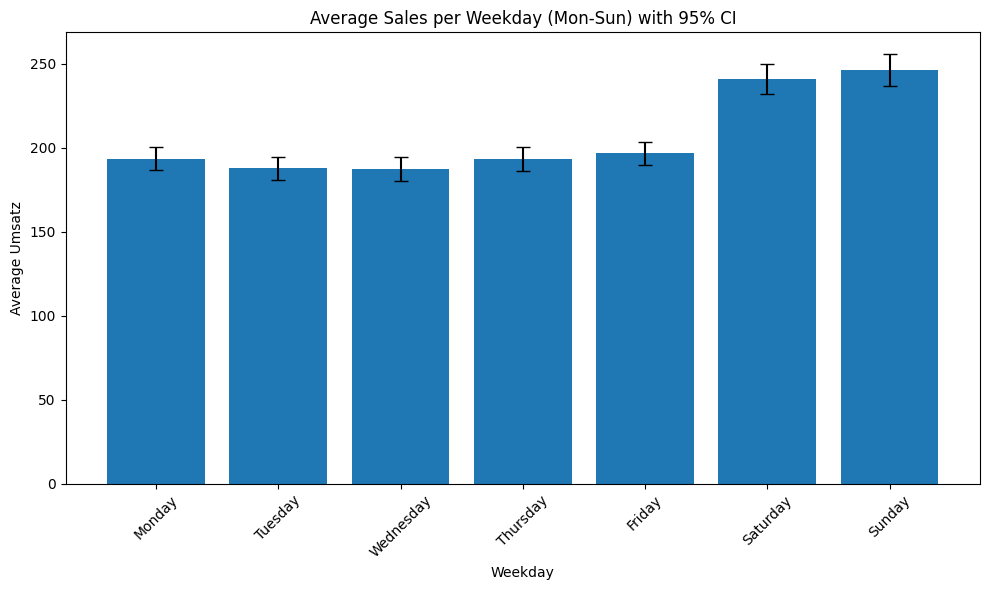

In [41]:
# Group by weekday (Monday to Sunday) and calculate mean and confidence interval
weekday_data_full = data[data['Wochentag'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])]

# Calculate mean and 95% confidence intervals
summary_stats = weekday_data_full.groupby('Wochentag')['Umsatz'].agg(['mean', 'count', 'std'])
summary_stats['ci95'] = 1.96 * summary_stats['std'] / np.sqrt(summary_stats['count'])

# Reorder for plotting
summary_stats = summary_stats.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Plot with error bars for confidence intervals
plt.figure(figsize=(10, 6))
plt.bar(summary_stats.index, summary_stats['mean'], yerr=summary_stats['ci95'], capsize=5)
plt.title('Average Sales per Weekday (Mon-Sun) with 95% CI')
plt.xlabel('Weekday')
plt.ylabel('Average Umsatz')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

